In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load operational sample
operational = pd.read_excel("sampletrain.xlsx")

# Load TTE / repair-event information
tte = pd.read_csv("train_tte.csv")

print("Operational sample shape:", operational.shape)
print("TTE shape:", tte.shape)

Operational sample shape: (20035, 107)
TTE shape: (23550, 3)


In [3]:
print("Operational columns:")
print(operational.columns.tolist())

print("\nTTE columns:")
print(tte.columns.tolist())

Operational columns:
['vehicle_id', 'time_step', '171_0', '666_0', '427_0', '837_0', '167_0', '167_1', '167_2', '167_3', '167_4', '167_5', '167_6', '167_7', '167_8', '167_9', '309_0', '272_0', '272_1', '272_2', '272_3', '272_4', '272_5', '272_6', '272_7', '272_8', '272_9', '835_0', '370_0', '291_0', '291_1', '291_2', '291_3', '291_4', '291_5', '291_6', '291_7', '291_8', '291_9', '291_10', '158_0', '158_1', '158_2', '158_3', '158_4', '158_5', '158_6', '158_7', '158_8', '158_9', '100_0', '459_0', '459_1', '459_2', '459_3', '459_4', '459_5', '459_6', '459_7', '459_8', '459_9', '459_10', '459_11', '459_12', '459_13', '459_14', '459_15', '459_16', '459_17', '459_18', '459_19', '397_0', '397_1', '397_2', '397_3', '397_4', '397_5', '397_6', '397_7', '397_8', '397_9', '397_10', '397_11', '397_12', '397_13', '397_14', '397_15', '397_16', '397_17', '397_18', '397_19', '397_20', '397_21', '397_22', '397_23', '397_24', '397_25', '397_26', '397_27', '397_28', '397_29', '397_30', '397_31', '397_32',

In [4]:
### EDA 1 — Dataset Overview
operational.head()

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,167_7,167_8,167_9,309_0,272_0,272_1,272_2,272_3,272_4,272_5,272_6,272_7,272_8,272_9,835_0,370_0,291_0,291_1,291_2,291_3,291_4,291_5,291_6,291_7,291_8,291_9,291_10,158_0,158_1,158_2,158_3,158_4,158_5,158_6,158_7,158_8,158_9,100_0,459_0,459_1,459_2,459_3,459_4,459_5,459_6,459_7,459_8,459_9,459_10,459_11,459_12,459_13,459_14,459_15,459_16,459_17,459_18,459_19,397_0,397_1,397_2,397_3,397_4,397_5,397_6,397_7,397_8,397_9,397_10,397_11,397_12,397_13,397_14,397_15,397_16,397_17,397_18,397_19,397_20,397_21,397_22,397_23,397_24,397_25,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,11.2,167985,10787,7413813.0,2296,4110.0,1296420.0,1628265.0,630345.0,1269525.0,4772940.0,2706706.0,222225.0,6240.0,0.0,70,1435083.0,857662.0,384579.0,668642.0,7239843.0,398490.0,3887.0,0.0,0.0,0.0,8036751.0,0.0,1227.0,555.0,463.0,925.0,468.0,225.0,535.0,516.0,492.0,729.0,66.0,97056.0,2690052.0,2945268.0,788437.0,687480.0,595164.0,491232.0,532932.0,809628.0,505693.0,858410.0,203.676778,111.911500,147.265389,200.479944,230.306278,277.722417,315.748806,372.164528,864.246250,920.881111,637.901639,744.618944,880.866889,1272.323972,1847.623667,940.785694,2.900083,0.208444,0.056417,0.058444,446956.0,411420.0,203024.0,26636.0,29156.0,7616.0,449537.0,233352.0,139920.0,12648.0,2813.0,224.0,53161.0,178881.0,138250.0,13328.0,3581.0,88.0,16361.0,131601.0,116541.0,13506.0,2856.0,48.0,6337.0,105412.0,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0
1,0,11.4,167985,10787,7413813.0,2296,4111.0,1302855.0,1628265.0,630345.0,1269526.0,4772940.0,2706706.0,222225.0,6240.0,0.0,70,1440661.0,857662.0,384579.0,668642.0,7239843.0,398490.0,3887.0,0.0,0.0,0.0,8040811.0,0.0,1230.0,558.0,463.0,925.0,469.0,226.0,535.0,516.0,493.0,729.0,66.0,97056.0,2693100.0,2947368.0,788437.0,687480.0,595164.0,491232.0,532932.0,809628.0,505693.0,860571.0,204.256750,112.924250,147.265389,201.479944,230.306278,277.722417,315.748806,372.164528,864.246250,920.881111,637.901639,745.618944,880.866889,1272.323972,1847.623667,940.785694,2.900083,0.208444,0.056417,0.058444,446964.0,411420.0,203027.0,26638.0,29157.0,7616.0,451193.0,233354.0,139920.0,12649.0,2813.0,224.0,53210.0,178883.0,138252.0,13328.0,3582.0,88.0,16368.0,131601.0,116542.0,13507.0,2856.0,48.0,6339.0,105413.0,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0
2,0,19.6,331635,14525,13683604.0,2600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70,1787736.0,1133132.0,598351.0,1167062.0,12314224.0,460240.0,3887.0,0.0,0.0,0.0,12777022.0,0.0,2136.0,954.0,850.0,1420.0,722.0,412.0,880.0,666.0,586.0,1143.0,162.0,181632.0,4249020.0,4630440.0,1539133.0,1421172.0,1039764.0,749472.0,740724.0,995796.0,574045.0,1379191.0,321.671972,157.312500,193.792833,263.577611,310.711861,366.149250,415.642472,484.391167,1146.111611,1286.536333,900.062917,1123.232556,1449.545611,2140.037472,5046.748278,1151.010139,3.320194,0.218806,0.056778,0.058444,756665.0,647348.0,286811.0,30967.0,31213.0,7745.0,633790.0,423395.0,271940.0,16190.0,3573.0,232.0,75038.0,352791.0,327992.0,17325.0,4451.0,92.0,24028.0,234737.0,216619.0,17000.0,3476.0,48.0,12055.0,167693.0,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0
3,0,20.2,354975,15015,14540449.0,2616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70,1824409.0,1166074.0,634595.0,1233908.0,13275730.0,466753.0,3887.0,0.0,0.0,0.0,13612083.0,0.0,2218.0,1014.0,892.0,1471.0,749.0,425.0,901.0,702.0,589.0,1197.0,174.0,193728.0,4462548.0,4988028.0,1696022.0,1565484.0,1112544.0,789228.0,774588.0,1015104.0,576901.0,1428606.0,331.479028,162.731639,198.104472,269.712889,320.087333,377.478667,425.901361,495.749583,1173.882583,1323.460972,923.099361,1161.893139,1501.973944,2208.782833,5587.856667,1160.593833,3.336417,0.218806,0.056778,0.058444,812577.0,686860.0,302955.0,31927.0,31488.0,7749.0,651902.0,478279.0,292109.0,16755.0,3753.0,232.0,77118.0,394083.0,359060.0,17941.0,4573.0,92.0

In [5]:
operational.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20035 entries, 0 to 20034
Columns: 107 entries, vehicle_id to 397_35
dtypes: float64(102), int64(5)
memory usage: 16.4 MB


In [6]:
identifier_columns = ["vehicle_id", "time_step"]

sensor_columns = [
    col for col in operational.columns
    if col not in identifier_columns
]

print("Number of operational/sensor columns:", len(sensor_columns))

print("\nSensor/operational columns:")
print(sensor_columns)

Number of operational/sensor columns: 105

Sensor/operational columns:
['171_0', '666_0', '427_0', '837_0', '167_0', '167_1', '167_2', '167_3', '167_4', '167_5', '167_6', '167_7', '167_8', '167_9', '309_0', '272_0', '272_1', '272_2', '272_3', '272_4', '272_5', '272_6', '272_7', '272_8', '272_9', '835_0', '370_0', '291_0', '291_1', '291_2', '291_3', '291_4', '291_5', '291_6', '291_7', '291_8', '291_9', '291_10', '158_0', '158_1', '158_2', '158_3', '158_4', '158_5', '158_6', '158_7', '158_8', '158_9', '100_0', '459_0', '459_1', '459_2', '459_3', '459_4', '459_5', '459_6', '459_7', '459_8', '459_9', '459_10', '459_11', '459_12', '459_13', '459_14', '459_15', '459_16', '459_17', '459_18', '459_19', '397_0', '397_1', '397_2', '397_3', '397_4', '397_5', '397_6', '397_7', '397_8', '397_9', '397_10', '397_11', '397_12', '397_13', '397_14', '397_15', '397_16', '397_17', '397_18', '397_19', '397_20', '397_21', '397_22', '397_23', '397_24', '397_25', '397_26', '397_27', '397_28', '397_29', '397_3

In [7]:
operational[sensor_columns].dtypes.value_counts()

float64    101
int64        4
Name: count, dtype: int64

In [8]:
numeric_sensor_columns = operational[sensor_columns].select_dtypes(
    include=np.number
).columns.tolist()

print("Number of numeric sensor/operational features:",
      len(numeric_sensor_columns))

Number of numeric sensor/operational features: 105


In [9]:
### EDA 2 — Missing-Value Analysis
missing_count = operational.isnull().sum()
missing_percent = (missing_count / len(operational)) * 100

missing_table = pd.DataFrame({
    "Feature": operational.columns,
    "Missing Count": missing_count.values,
    "Missing %": missing_percent.values
})

missing_table = missing_table[
    missing_table["Missing Count"] > 0
].sort_values(
    by="Missing %",
    ascending=False
)

missing_table

,Feature,Missing Count,Missing %
6,167_0,549,2.740205
7,167_1,549,2.740205
8,167_2,549,2.740205
9,167_3,549,2.740205
10,167_4,549,2.740205
...,...,...,...
24,272_7,2,0.009983
25,272_8,2,0.009983
26,272_9,2,0.009983
17,272_0,2,0.009983


In [10]:
### EDA 2 — Missing-Value Analysis
missing_table_sensor = missing_table[
    missing_table["Feature"].isin(sensor_columns)
]

missing_table_sensor.head(20)

,Feature,Missing Count,Missing %
6,167_0,549,2.740205
7,167_1,549,2.740205
8,167_2,549,2.740205
9,167_3,549,2.740205
10,167_4,549,2.740205
11,167_5,549,2.740205
12,167_6,549,2.740205
13,167_7,549,2.740205
14,167_8,549,2.740205
15,167_9,549,2.740205


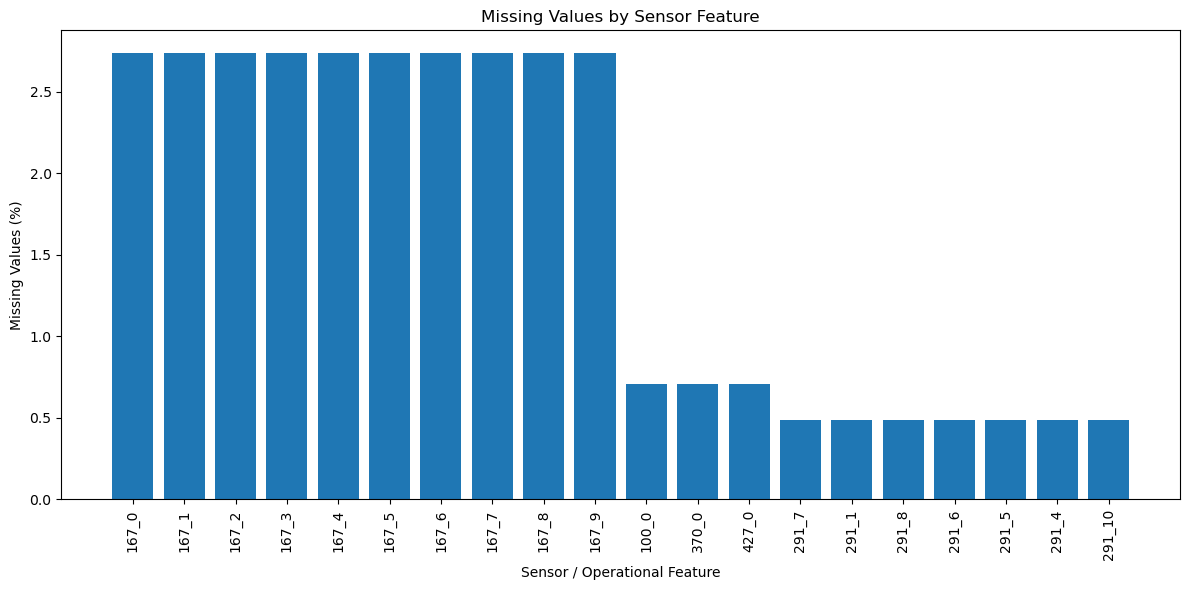

In [11]:
plt.figure(figsize=(12, 6))

missing_plot = missing_table_sensor.head(20)

plt.bar(
    missing_plot["Feature"],
    missing_plot["Missing %"]
)

plt.xticks(rotation=90)
plt.xlabel("Sensor / Operational Feature")
plt.ylabel("Missing Values (%)")
plt.title("Missing Values by Sensor Feature")

plt.tight_layout()
plt.savefig("missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
duplicate_count = operational.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [13]:
eda_df = operational.merge(
    tte,
    on="vehicle_id",
    how="left"
)

print("Merged shape:", eda_df.shape)

print("\nRepair/event distribution:")
print(eda_df["in_study_repair"].value_counts())

Merged shape: (20035, 109)

Repair/event distribution:
in_study_repair
0    17409
1     2626
Name: count, dtype: int64


In [14]:
vehicle_event_status = (
    eda_df[["vehicle_id", "in_study_repair"]]
    .drop_duplicates()
)

print(
    vehicle_event_status["in_study_repair"]
    .value_counts()
)

in_study_repair
0    188
1     28
Name: count, dtype: int64


In [15]:
### EDA 3 — Vehicle/Component Distribution
event_distribution = (
    vehicle_event_status["in_study_repair"]
    .value_counts(normalize=True) * 100
)

event_distribution

in_study_repair
0    87.037037
1    12.962963
Name: proportion, dtype: float64

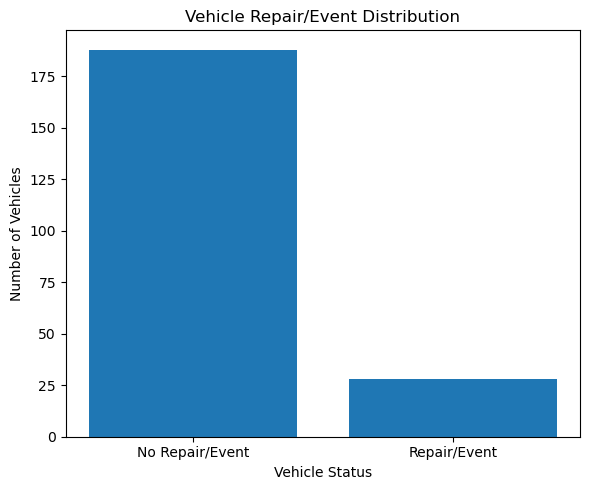

In [16]:
counts = vehicle_event_status["in_study_repair"].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    ["No Repair/Event", "Repair/Event"],
    [
        counts.get(0, 0),
        counts.get(1, 0)
    ]
)

plt.xlabel("Vehicle Status")
plt.ylabel("Number of Vehicles")
plt.title("Vehicle Repair/Event Distribution")

plt.tight_layout()
plt.show()

In [17]:
tte.head()

,vehicle_id,length_of_study_time_step,in_study_repair
0,0,510.0,0
1,2,281.8,0
2,3,293.4,0
3,4,210.0,0
4,5,360.4,0


In [18]:
print(tte["in_study_repair"].value_counts())

in_study_repair
0    21278
1     2272
Name: count, dtype: int64


In [19]:
eda_df["RUL"] = (
    eda_df["length_of_study_time_step"]
    - eda_df["time_step"]
)

In [20]:
rul_df = eda_df[
    eda_df["in_study_repair"] == 1
].copy()

In [21]:
print("Rows with observed repair/event:", len(rul_df))

print("\nRUL statistics:")
print(rul_df["RUL"].describe())

Rows with observed repair/event: 2626

RUL statistics:
count    2626.000000
mean      195.423382
std       122.797032
min         0.200000
25%        91.450000
50%       181.200000
75%       291.200000
max       482.000000
Name: RUL, dtype: float64


In [22]:
print("Negative RUL values:", (rul_df["RUL"] < 0).sum())
print("Zero RUL values:", (rul_df["RUL"] == 0).sum())

Negative RUL values: 0
Zero RUL values: 0


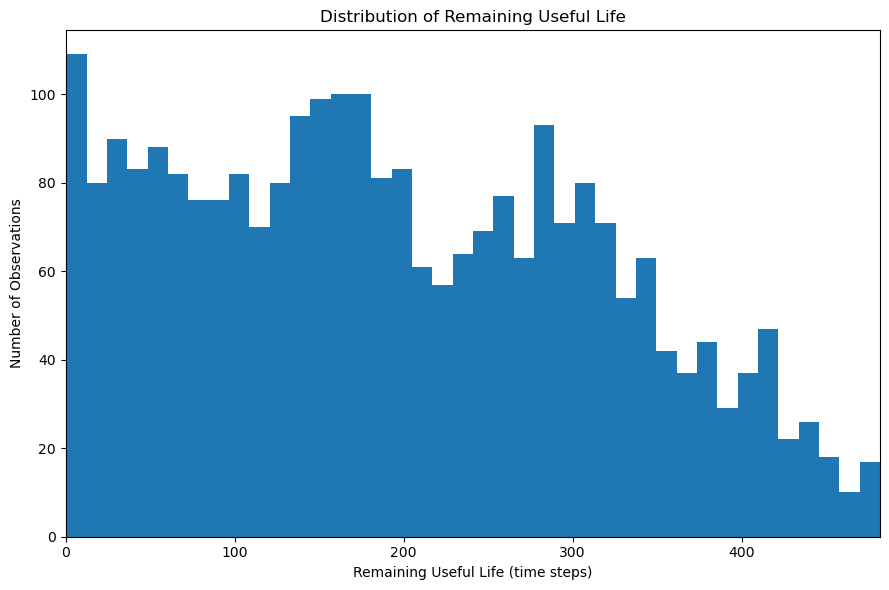

In [23]:
### EDA 6 — RUL Distribution
plt.figure(figsize=(9, 6))

plt.hist(
    rul_df["RUL"],
    bins=40
)

plt.xlabel("Remaining Useful Life (time steps)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Remaining Useful Life")

plt.xlim(0, rul_df["RUL"].max())
plt.tight_layout()
plt.savefig("rul_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
rul_stats = rul_df["RUL"].describe()

rul_stats

count    2626.000000
mean      195.423382
std       122.797032
min         0.200000
25%        91.450000
50%       181.200000
75%       291.200000
max       482.000000
Name: RUL, dtype: float64

In [25]:
time_counts = (
    operational["time_step"]
    .value_counts()
    .sort_index()
)

time_counts.head()

time_step
0.0    29
0.2     5
0.4     6
0.6    11
0.8     7
Name: count, dtype: int64

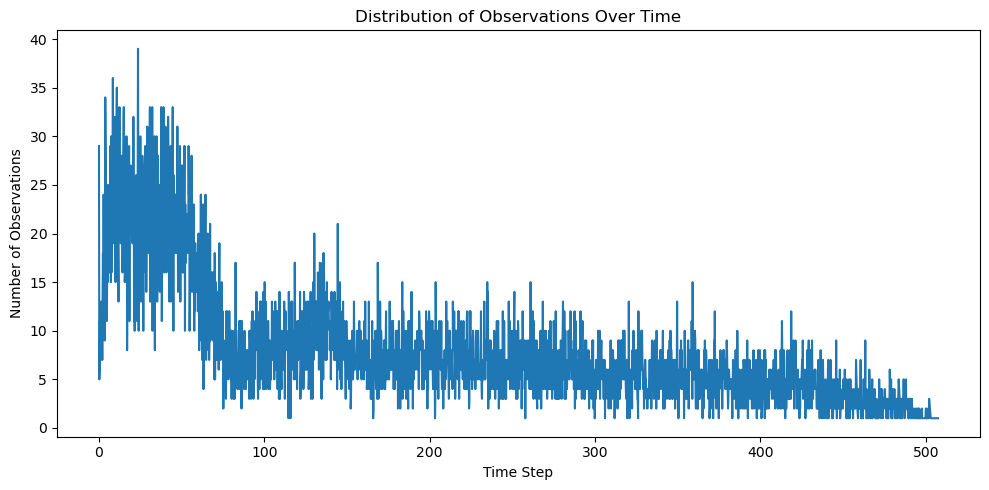

In [26]:
### EDA 4 — Time Distribution
plt.figure(figsize=(10, 5))

plt.plot(
    time_counts.index,
    time_counts.values
)

plt.xlabel("Time Step")
plt.ylabel("Number of Observations")
plt.title("Distribution of Observations Over Time")

plt.tight_layout()
plt.show()

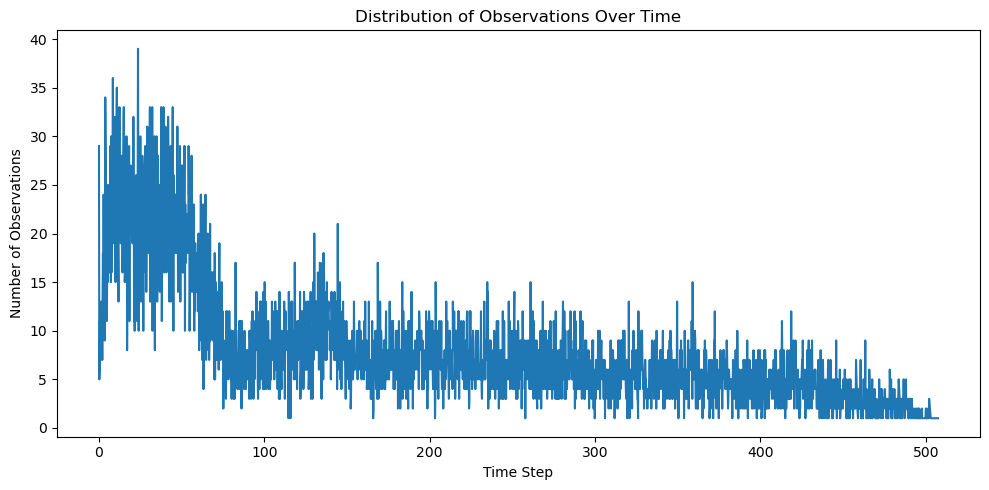

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_counts.index,
    time_counts.values
)

plt.xlabel("Time Step")
plt.ylabel("Number of Observations")
plt.title("Distribution of Observations Over Time")

plt.tight_layout()
plt.show()

In [28]:
print("Minimum time:", operational["time_step"].min())
print("Maximum time:", operational["time_step"].max())

Minimum time: 0.0
Maximum time: 507.4


In [29]:
### EDA 5 — Sensor-Value Distribution
selected_sensors = numeric_sensor_columns[:6]

print(selected_sensors)

['171_0', '666_0', '427_0', '837_0', '167_0', '167_1']


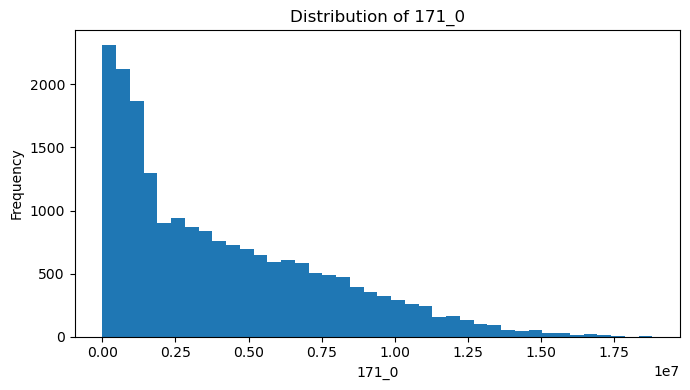

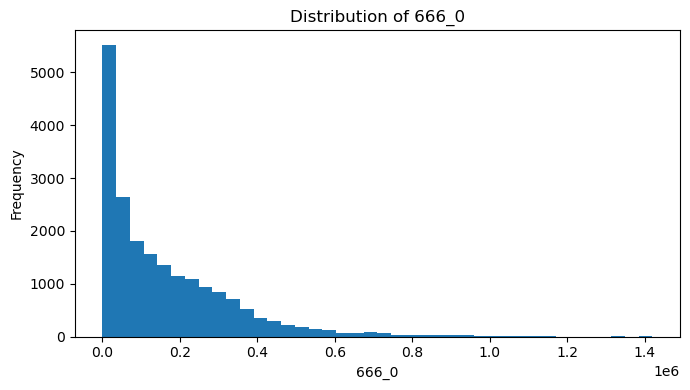

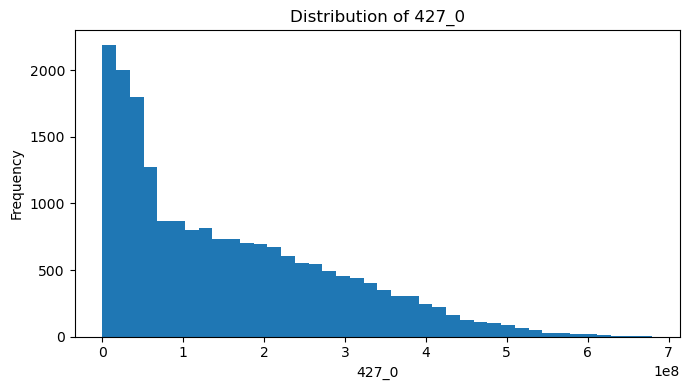

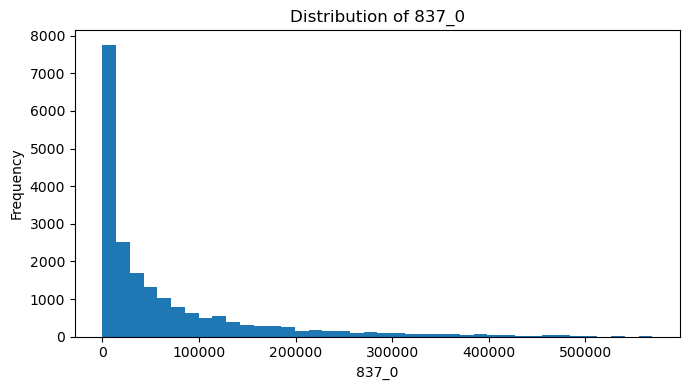

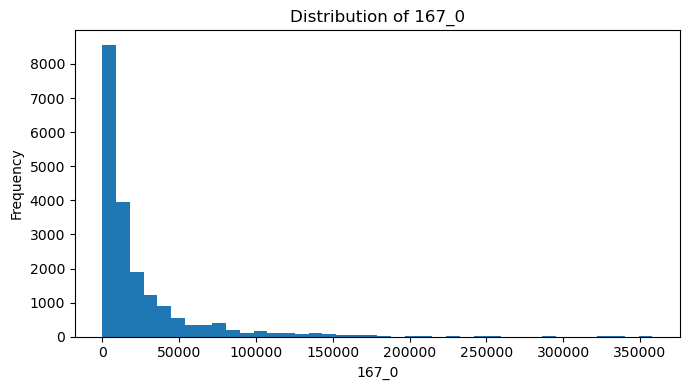

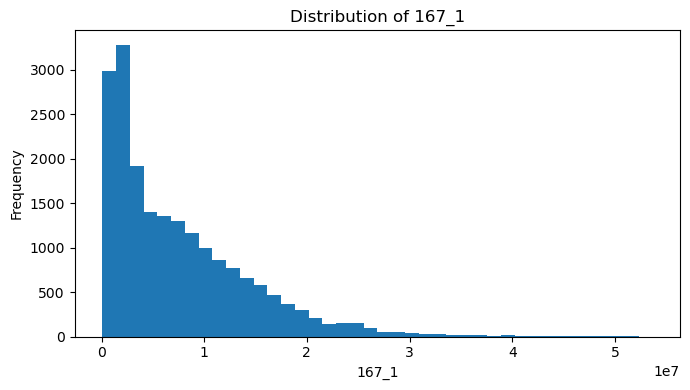

In [30]:
for feature in selected_sensors:
    plt.figure(figsize=(7, 4))

    plt.hist(
        operational[feature].dropna(),
        bins=40
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature}")

    plt.tight_layout()
    plt.show()

In [31]:
### EDA 7 — Sensor Correlation Analysis
correlation_df = rul_df[
    numeric_sensor_columns + ["RUL"]
]

correlation_with_rul = (
    correlation_df.corr(numeric_only=True)["RUL"]
    .drop("RUL")
    .sort_values()
)

print("Most negative correlations:")
print(correlation_with_rul.head(10))

print("\nMost positive correlations:")
print(correlation_with_rul.tail(10))

Most negative correlations:
397_0    -0.652458
397_24   -0.640059
397_20   -0.627430
272_0    -0.616197
158_1    -0.614788
167_1    -0.597097
158_0    -0.592379
158_6    -0.584576
167_3    -0.580332
397_14   -0.574540
Name: RUL, dtype: float64

Most positive correlations:
397_5    -0.158278
272_8    -0.157958
397_7    -0.157405
272_3    -0.141461
272_7    -0.140238
459_18   -0.135937
272_9    -0.110489
459_19   -0.109053
397_13   -0.082001
397_2    -0.068419
Name: RUL, dtype: float64


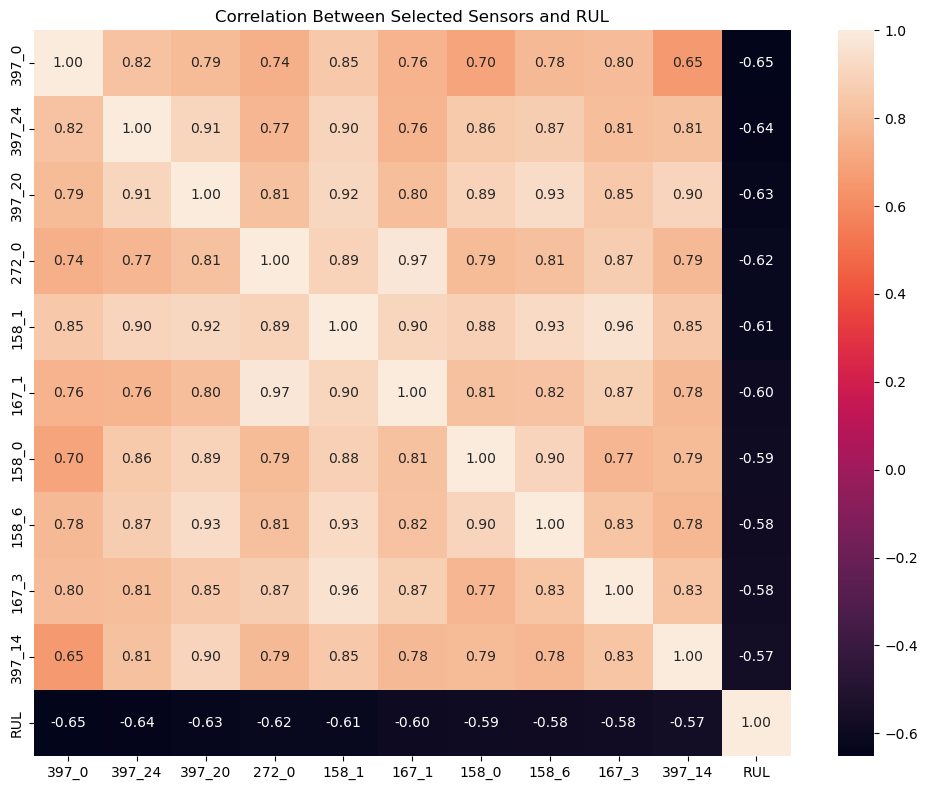

In [40]:
top_corr_features = (
    correlation_with_rul.abs()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

heatmap_columns = top_corr_features + ["RUL"]

plt.figure(figsize=(10, 8))

sns.heatmap(
    rul_df[heatmap_columns].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Selected Sensors and RUL")

plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
event_vehicles = (
    rul_df["vehicle_id"]
    .drop_duplicates()
    .tolist()
)

selected_vehicles = event_vehicles[:3]

print("Selected vehicles:", selected_vehicles)

Selected vehicles: [22, 27, 29]


In [34]:
time_series_sensors = numeric_sensor_columns[:3]

print("Selected sensors:", time_series_sensors)

Selected sensors: ['171_0', '666_0', '427_0']


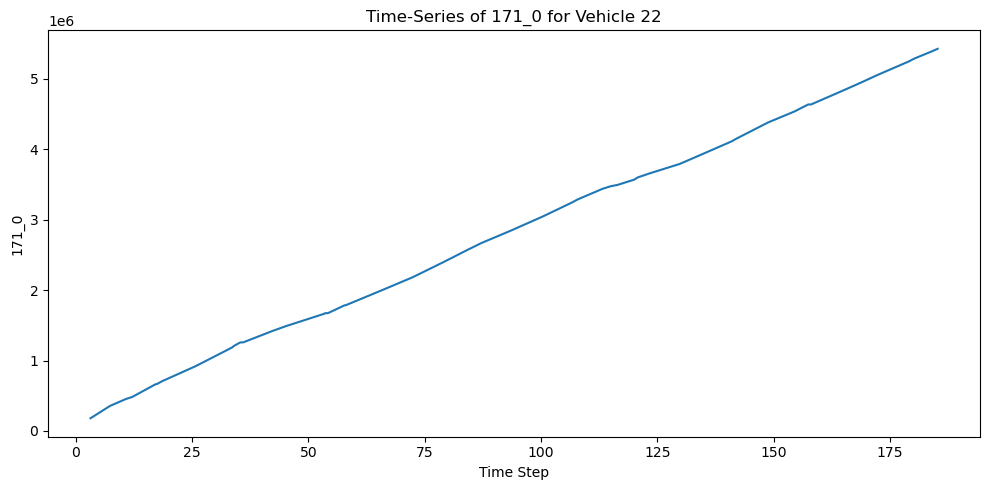

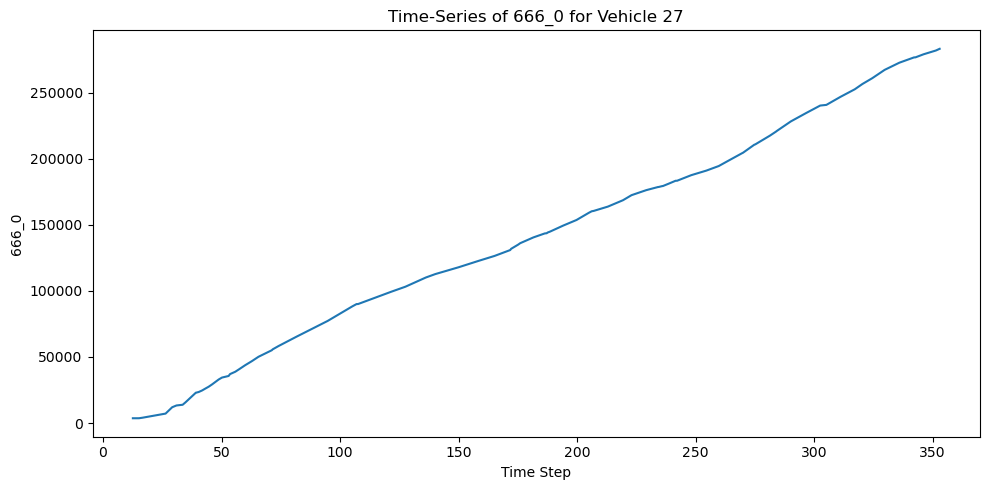

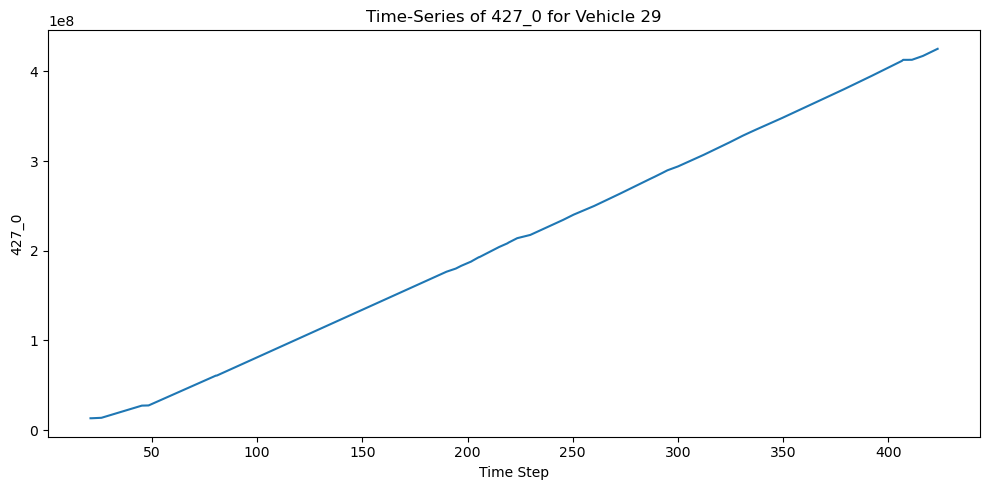

In [41]:
### EDA 8 — Example Time-Series Visualizations
for vehicle, sensor in zip(
    selected_vehicles,
    time_series_sensors
):
    
    vehicle_data = (
        rul_df[rul_df["vehicle_id"] == vehicle]
        .sort_values("time_step")
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        vehicle_data["time_step"],
        vehicle_data[sensor]
    )

    plt.xlabel("Time Step")
    plt.ylabel(sensor)
    plt.title(
        f"Time-Series of {sensor} for Vehicle {vehicle}"
    )

    plt.tight_layout()
    plt.savefig("time_series.png", dpi=300, bbox_inches="tight")
    plt.show()

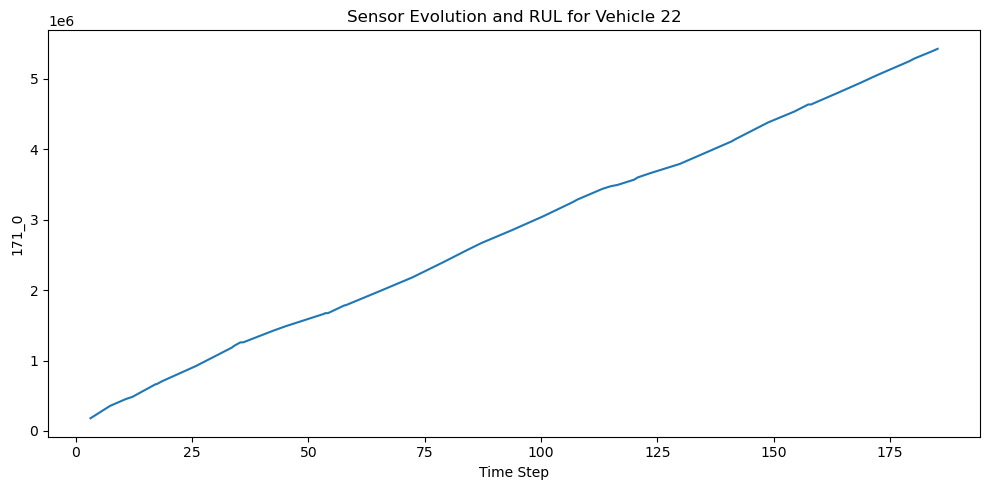

In [36]:
vehicle = selected_vehicles[0]

vehicle_data = (
    rul_df[rul_df["vehicle_id"] == vehicle]
    .sort_values("time_step")
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    vehicle_data["time_step"],
    vehicle_data[time_series_sensors[0]]
)

ax1.set_xlabel("Time Step")
ax1.set_ylabel(time_series_sensors[0])

plt.title(
    f"Sensor Evolution and RUL for Vehicle {vehicle}"
)

plt.tight_layout()
plt.show()

In [37]:
observations_per_vehicle = (
    operational.groupby("vehicle_id")
    .size()
)

print(observations_per_vehicle.describe())

count    216.000000
mean      92.754630
std       45.040447
min        8.000000
25%       56.000000
50%       94.500000
75%      126.250000
max      237.000000
dtype: float64


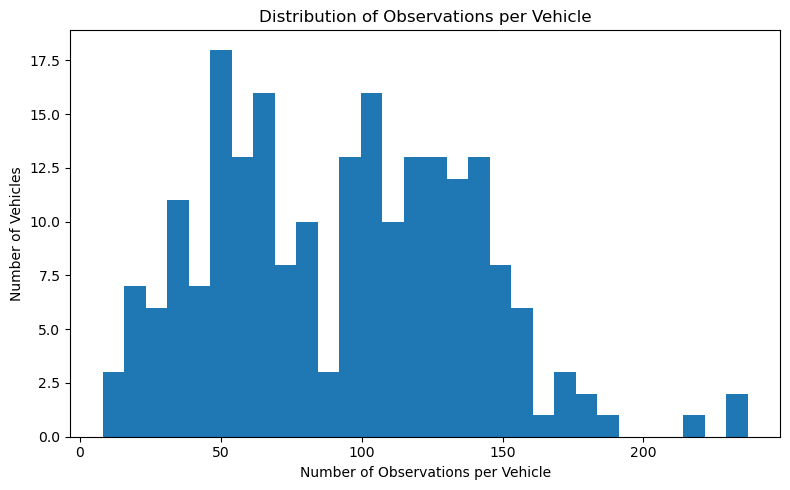

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    observations_per_vehicle,
    bins=30
)

plt.xlabel("Number of Observations per Vehicle")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Observations per Vehicle")

plt.tight_layout()
plt.show()